**Analisis_Sentimen_Ulasan_Aplikasi_seabank_di_Playstore_Algoritma_SVM**

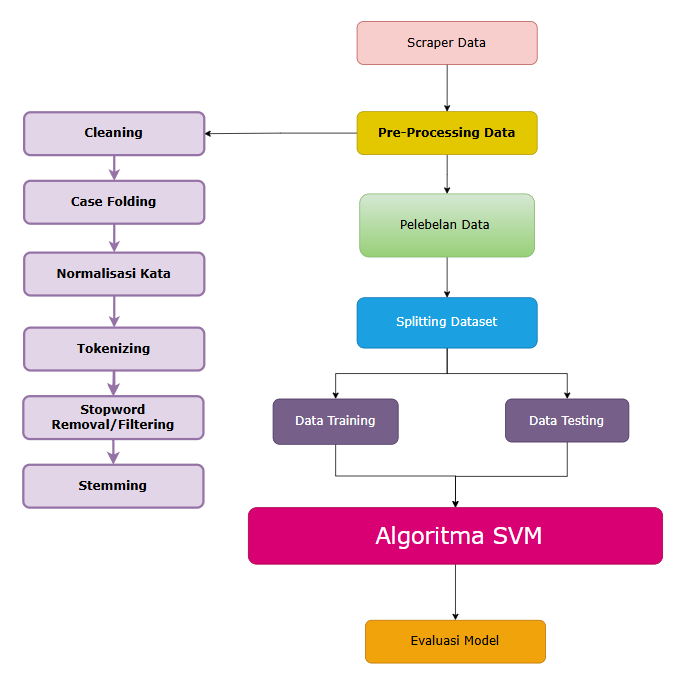

# ***SCRAPING DATA***

In [ ]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 600.1 kB/s eta 0:00:00


In [ ]:
from google_play_scraper import app, reviews
import pandas as pd
import datetime

google_play_scraper: Library ini digunakan untuk mengambil informasi aplikasi dan ulasan dari Google Play Store.
pandas: Digunakan untuk bekerja dengan data dalam format DataFrame.
datetime: Digunakan untuk menentukan rentang waktu (start_date dan end_date).

In [ ]:
from google_play_scraper import reviews, Sort

app_id = 'id.co.bankbkemobile.digitalbank'

def get_reviews(app_id, lang='id', count=10000, sort=Sort.NEWEST, filter_score_with=None, filter_device_with=None, continuation_token=None):
    try:
        result, continuation_token = reviews(
            app_id,
            lang=lang,
            country='id',
            sort=sort,
            count=count,
            filter_score_with=filter_score_with,
            filter_device_with=filter_device_with,
            continuation_token=continuation_token
        )

        return result, continuation_token
    except Exception as e:
        print("Error:", e)
        return None, None

reviews, continuation_token = get_reviews(app_id)

if reviews is not None:
    print("Jumlah ulasan:", len(reviews))
    if len(reviews) > 0:
        print("Contoh ulasan:")
        print(reviews[0])
else:
    print("Tidak dapat mengambil ulasan.")


Jumlah ulasan: 10000
Contoh ulasan:
{'reviewId': 'f0e8f1b1-fffa-49a2-ae08-d89c3b0d54c1', 'userName': 'Pengguna Google', 'userImage': 'https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g', 'content': 'Top oke harga terjangkau,program & internalnya lebih mudah dipahami,bebas iklan,bug,ataupun lelet,enak ketika dijalankan & mengakses smua fitur2nya. Tapi di sayangkan sering ketika pakai terkadang agak" sulit membukanya pas saat koneksi lagi buruk / tidak stabil,terkadang loadingnya lambat banget dan cuma berputar-putar saja. mungkin beberapa hal yang biasa terjadi di apps ini dan yang lain-lainnya sesuai pengalaman transaksi sukses,, masukan tuk bagusnya dibenahi tiap permasalahan.ok bnget', 'score': 5, 'thumbsUpCount': 0, 'reviewCreatedVersion': None, 'at': datetime.datetime(2026, 6, 14, 14, 29, 30), 'replyContent': None, 'repliedAt': None, 'appVersion': None}


In [ ]:
import csv

def export_to_csv(reviews, file_name='hasil_scraper_ulasan_app_seabank.csv'):
    if reviews:
        fieldnames = ['Review ID', 'Username', 'Rating', 'Review Text', 'Date']

        with open(file_name, mode='w', newline='', encoding='utf-8') as csv_file:
            writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
            writer.writeheader()

            for review in reviews:
                writer.writerow({
                    'Review ID': review['reviewId'],
                    'Username': review['userName'],
                    'Rating': review['score'],
                    'Review Text': review['content'],
                    'Date': review['at']
                })

        print(f"Data berhasil diekspor ke '{file_name}'")
    else:
        print("Tidak ada data ulasan untuk diekspor.")

export_to_csv(reviews)


Data berhasil diekspor ke 'hasil_scraper_ulasan_app_seabank.csv'


In [ ]:
import pandas as pd

data = pd.read_csv("hasil_scraper_ulasan_app_seabank.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Review ID    10000 non-null  object
 1   Username     10000 non-null  object
 2   Rating       10000 non-null  int64 
 3   Review Text  10000 non-null  object
 4   Date         10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB


In [ ]:
data.head(20)

,Review ID,Username,Rating,Review Text,Date
0,f0e8f1b1-fffa-49a2-ae08-d89c3b0d54c1,Pengguna Google,5,"Top oke harga terjangkau,program & internalnya...",2026-06-14 14:29:30
1,4c111922-37bc-48fd-8b3f-da89fa1c4a38,Pengguna Google,5,👍👍👍,2026-06-14 14:28:32
2,7a741855-e214-48bd-96f4-a0de5bb08e6a,Pengguna Google,5,MANTAAAAAAPPP,2026-06-14 14:26:42
3,905da055-d114-4f9f-b13d-ba0ae838203f,Pengguna Google,5,nice,2026-06-14 14:25:52
4,c0fdbd29-1f12-4699-a0b0-29284a6744c0,Pengguna Google,5,bagus,2026-06-14 14:25:42
5,64e38d97-ab1f-470a-b7e0-332c58e77117,Pengguna Google,5,puas banyak geratisan . kalau bisa Ada dana pi...,2026-06-14 14:23:30
6,7848dd71-1676-44af-898c-ba3438c8a0b3,Pengguna Google,5,baik,2026-06-14 14:19:34
7,bd66bddc-4d07-4adc-a5d9-dfc744dc9ea6,Pengguna Google,5,Senang nabung di seabank lumayan ada bunga per...,2026-06-14 14:13:11
8,20de6357-5757-4c90-ad03-abd4faa152a0,Pengguna Google,5,Terbaik,2026-06-14 14:12:28
9,ccd2bc3a-de85-495f-a036-42e190816a7a,Pengguna Google,5,nyaman banget,2026-06-14 14:11:23


# ***PREPROCESSING DATA***

kalau upload data manual dari local, pake ini

In [1]:
from google.colab import files
import pandas as pd

# Mengunggah file dari komputer lokal
print("Silakan pilih file CSV Anda:")
uploaded = files.upload()

# Dapatkan nama file yang diunggah (asumsi hanya satu file yang diunggah)
for fn in uploaded.keys():
  print(f"File '{fn}' berhasil diunggah")
  uploaded_file_name = fn

# Baca file CSV ke dalam DataFrame pandas
df_local = pd.read_csv(uploaded_file_name)

# Menampilkan informasi dan beberapa baris pertama dari DataFrame
print("\nInformasi DataFrame:")
df_local.info()
print("\n5 baris pertama DataFrame:")
df_local.head()

Silakan pilih file CSV Anda:


Saving hasil_scraper_ulasan_app_seabank.csv to hasil_scraper_ulasan_app_seabank.csv
File 'hasil_scraper_ulasan_app_seabank.csv' berhasil diunggah

Informasi DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Review ID    10000 non-null  object
 1   Username     10000 non-null  object
 2   Rating       10000 non-null  int64 
 3   Review Text  10000 non-null  object
 4   Date         10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB

5 baris pertama DataFrame:


,Review ID,Username,Rating,Review Text,Date
0,61e44b1f-5a26-4568-a66d-46ecf485b3fd,Pengguna Google,5,sangat puas,2026-04-25 11:58:49
1,1114ee1d-8865-42e9-a861-2e75aaabbf5a,Pengguna Google,4,Semoga untuk penyimpanan tetap aman.Sekedar sa...,2026-04-25 11:57:16
2,60205c03-c96c-47a2-95ca-850be2ea00d7,Pengguna Google,5,mantap bosku 🙏,2026-04-25 11:52:01
3,b617b604-637f-43eb-b0ad-85d3f614ff9f,Pengguna Google,5,Àplikasi bank digital yang bagus cepat dan lancar,2026-04-25 11:24:37
4,97b1a438-3fdb-4453-af7b-fda2c8505aca,Pengguna Google,1,saya tidak bisa membuka seabank,2026-04-25 10:59:01


In [2]:
import pandas as pd

data = pd.read_csv("hasil_scraper_ulasan_app_seabank.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Review ID    10000 non-null  object
 1   Username     10000 non-null  object
 2   Rating       10000 non-null  int64 
 3   Review Text  10000 non-null  object
 4   Date         10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB


In [3]:
data.head(5)

,Review ID,Username,Rating,Review Text,Date
0,61e44b1f-5a26-4568-a66d-46ecf485b3fd,Pengguna Google,5,sangat puas,2026-04-25 11:58:49
1,1114ee1d-8865-42e9-a861-2e75aaabbf5a,Pengguna Google,4,Semoga untuk penyimpanan tetap aman.Sekedar sa...,2026-04-25 11:57:16
2,60205c03-c96c-47a2-95ca-850be2ea00d7,Pengguna Google,5,mantap bosku 🙏,2026-04-25 11:52:01
3,b617b604-637f-43eb-b0ad-85d3f614ff9f,Pengguna Google,5,Àplikasi bank digital yang bagus cepat dan lancar,2026-04-25 11:24:37
4,97b1a438-3fdb-4453-af7b-fda2c8505aca,Pengguna Google,1,saya tidak bisa membuka seabank,2026-04-25 10:59:01


In [4]:
df  = pd.DataFrame(data[['Date','Username','Rating','Review Text']])
df.head(5)

,Date,Username,Rating,Review Text
0,2026-04-25 11:58:49,Pengguna Google,5,sangat puas
1,2026-04-25 11:57:16,Pengguna Google,4,Semoga untuk penyimpanan tetap aman.Sekedar sa...
2,2026-04-25 11:52:01,Pengguna Google,5,mantap bosku 🙏
3,2026-04-25 11:24:37,Pengguna Google,5,Àplikasi bank digital yang bagus cepat dan lancar
4,2026-04-25 10:59:01,Pengguna Google,1,saya tidak bisa membuka seabank


**PROSES HAPUS DATA DUPLIKAT**

---



In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         10000 non-null  object
 1   Username     10000 non-null  object
 2   Rating       10000 non-null  int64 
 3   Review Text  10000 non-null  object
dtypes: int64(1), object(3)
memory usage: 312.6+ KB


In [6]:
df.drop_duplicates(subset ="Review Text", keep = 'first', inplace = True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5623 entries, 0 to 9993
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         5623 non-null   object
 1   Username     5623 non-null   object
 2   Rating       5623 non-null   int64 
 3   Review Text  5623 non-null   object
dtypes: int64(1), object(3)
memory usage: 219.6+ KB


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5623 entries, 0 to 9993
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         5623 non-null   object
 1   Username     5623 non-null   object
 2   Rating       5623 non-null   int64 
 3   Review Text  5623 non-null   object
dtypes: int64(1), object(3)
memory usage: 219.6+ KB


**WORDCLOUD SEBELUM PREPROCESSING**

---



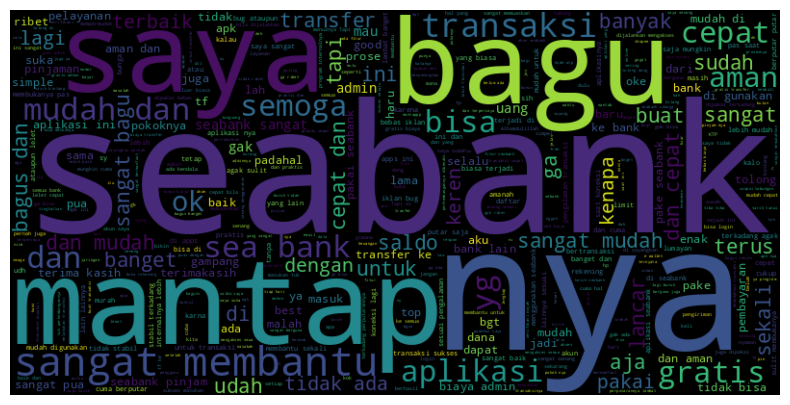

In [9]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt


# Mengisi nilai NaN dengan string kosong ('')
df['Review Text'] = df['Review Text'].fillna('')

# Menggabungkan teks dari kolom 'content'
text = ' '.join(df['Review Text'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp'])

wc = WordCloud(stopwords=stopwords, background_color="black", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

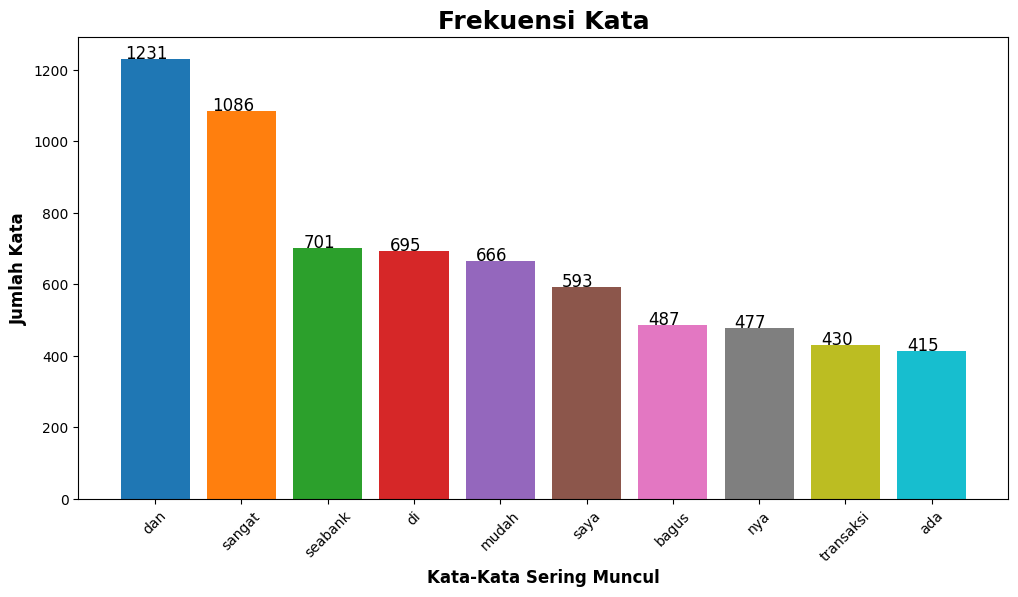

In [10]:
import matplotlib.pyplot as plt
from collections import Counter

text = " ".join(df["Review Text"])

tokens = text.split()
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)

word, count = zip(*top_words)

# Definisikan palet warna
colors = plt.cm.tab10(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')


plt.show()

**PROSES CLEANING**

---



In [11]:
import re
import string
import nltk
import pandas as pd

# Fungsi untuk menghapus URL
def remove_URL(tweet):
    if tweet is not None and isinstance(tweet, str):
        url = re.compile(r'https?://\S+|www\.\S+')
        return url.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus HTML
def remove_html(tweet):
    if tweet is not None and isinstance(tweet, str):
        html = re.compile(r'<.*?>')
        return html.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus emoji
def remove_emoji(tweet):
    if tweet is not None and isinstance(tweet, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F700-\U0001F77F"  # alchemical symbols
            u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
            u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
            u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
            u"\U0001FA00-\U0001FA6F"  # Chess Symbols
            u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
            u"\U0001F004-\U0001F0CF"  # Additional emoticons
            u"\U0001F1E0-\U0001F1FF"  # flags
                               "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus simbol
def remove_symbols(tweet):
    if tweet is not None and isinstance(tweet, str):
        # Replace all characters that are NOT letters, numbers, or whitespace with a single space
        cleaned_tweet = re.sub(r'[^a-zA-Z0-9\s]', ' ', tweet, flags=re.UNICODE)
        # Normalize multiple spaces to a single space and strip leading/trailing spaces
        cleaned_tweet = ' '.join(cleaned_tweet.split())
        return cleaned_tweet
    return tweet

# Fungsi untuk menghapus angka
def remove_numbers(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'\d', '', tweet)
    return tweet

# Fungsi untuk menghapus karakter yang berulang (misal: "bagusssss" -> "bagus")
def remove_repeated_chars(tweet):
    if tweet is not None and isinstance(tweet, str):
        return re.sub(r'(.)\1{2,}', r'\1', tweet)
    return tweet

df['cleaning'] = df['Review Text'].apply(lambda x: remove_URL(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_html(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_emoji(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_symbols(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_numbers(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_repeated_chars(x))

pd.set_option('display.max_colwidth', None)
df.head(50)


,Date,Username,Rating,Review Text,cleaning
0,2026-04-25 11:58:49,Pengguna Google,5,sangat puas,sangat puas
1,2026-04-25 11:57:16,Pengguna Google,4,Semoga untuk penyimpanan tetap aman.Sekedar saran nama pengirim/penerima ditampilkan penuh supaya lebih jelas.,Semoga untuk penyimpanan tetap aman Sekedar saran nama pengirim penerima ditampilkan penuh supaya lebih jelas
2,2026-04-25 11:52:01,Pengguna Google,5,mantap bosku 🙏,mantap bosku
3,2026-04-25 11:24:37,Pengguna Google,5,Àplikasi bank digital yang bagus cepat dan lancar,plikasi bank digital yang bagus cepat dan lancar
4,2026-04-25 10:59:01,Pengguna Google,1,saya tidak bisa membuka seabank,saya tidak bisa membuka seabank
5,2026-04-25 10:36:54,Pengguna Google,4,gratis lagi dong buat tf ke dana dan ewallet lainnya,gratis lagi dong buat tf ke dana dan ewallet lainnya
6,2026-04-25 09:58:35,Pengguna Google,5,"Transaksi cepat , murah dana aman",Transaksi cepat murah dana aman
7,2026-04-25 09:33:28,Pengguna Google,4,mantap...beda sama yang lain,mantap beda sama yang lain
8,2026-04-25 09:24:12,Pengguna Google,5,Sangat sangat membantu.,Sangat sangat membantu
9,2026-04-25 08:58:26,Pengguna Google,5,sangat membantu!!!,sangat membantu


**PROSES CASE FOLDING**

---



In [12]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

df['case_folding'] = df['cleaning'].apply(case_folding)
pd.set_option('display.max_colwidth', None)
df.head(50)

,Date,Username,Rating,Review Text,cleaning,case_folding
0,2026-04-25 11:58:49,Pengguna Google,5,sangat puas,sangat puas,sangat puas
1,2026-04-25 11:57:16,Pengguna Google,4,Semoga untuk penyimpanan tetap aman.Sekedar saran nama pengirim/penerima ditampilkan penuh supaya lebih jelas.,Semoga untuk penyimpanan tetap aman Sekedar saran nama pengirim penerima ditampilkan penuh supaya lebih jelas,semoga untuk penyimpanan tetap aman sekedar saran nama pengirim penerima ditampilkan penuh supaya lebih jelas
2,2026-04-25 11:52:01,Pengguna Google,5,mantap bosku 🙏,mantap bosku,mantap bosku
3,2026-04-25 11:24:37,Pengguna Google,5,Àplikasi bank digital yang bagus cepat dan lancar,plikasi bank digital yang bagus cepat dan lancar,plikasi bank digital yang bagus cepat dan lancar
4,2026-04-25 10:59:01,Pengguna Google,1,saya tidak bisa membuka seabank,saya tidak bisa membuka seabank,saya tidak bisa membuka seabank
5,2026-04-25 10:36:54,Pengguna Google,4,gratis lagi dong buat tf ke dana dan ewallet lainnya,gratis lagi dong buat tf ke dana dan ewallet lainnya,gratis lagi dong buat tf ke dana dan ewallet lainnya
6,2026-04-25 09:58:35,Pengguna Google,5,"Transaksi cepat , murah dana aman",Transaksi cepat murah dana aman,transaksi cepat murah dana aman
7,2026-04-25 09:33:28,Pengguna Google,4,mantap...beda sama yang lain,mantap beda sama yang lain,mantap beda sama yang lain
8,2026-04-25 09:24:12,Pengguna Google,5,Sangat sangat membantu.,Sangat sangat membantu,sangat sangat membantu
9,2026-04-25 08:58:26,Pengguna Google,5,sangat membantu!!!,sangat membantu,sangat membantu


**Normalisasi Kata**

---



In [13]:
import pandas as pd
import requests
from io import BytesIO

# Fungsi penggantian kata tidak baku
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash(word))
            else:
                replaced_words.append(word)
        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash

# Baca dataset kamu (pastikan df sudah tersedia)
data = pd.DataFrame(df[['Date','Username','Rating','Review Text','cleaning','case_folding']])
pd.set_option('display.max_colwidth', None)
data.head(50)

,Date,Username,Rating,Review Text,cleaning,case_folding
0,2026-04-25 11:58:49,Pengguna Google,5,sangat puas,sangat puas,sangat puas
1,2026-04-25 11:57:16,Pengguna Google,4,Semoga untuk penyimpanan tetap aman.Sekedar saran nama pengirim/penerima ditampilkan penuh supaya lebih jelas.,Semoga untuk penyimpanan tetap aman Sekedar saran nama pengirim penerima ditampilkan penuh supaya lebih jelas,semoga untuk penyimpanan tetap aman sekedar saran nama pengirim penerima ditampilkan penuh supaya lebih jelas
2,2026-04-25 11:52:01,Pengguna Google,5,mantap bosku 🙏,mantap bosku,mantap bosku
3,2026-04-25 11:24:37,Pengguna Google,5,Àplikasi bank digital yang bagus cepat dan lancar,plikasi bank digital yang bagus cepat dan lancar,plikasi bank digital yang bagus cepat dan lancar
4,2026-04-25 10:59:01,Pengguna Google,1,saya tidak bisa membuka seabank,saya tidak bisa membuka seabank,saya tidak bisa membuka seabank
5,2026-04-25 10:36:54,Pengguna Google,4,gratis lagi dong buat tf ke dana dan ewallet lainnya,gratis lagi dong buat tf ke dana dan ewallet lainnya,gratis lagi dong buat tf ke dana dan ewallet lainnya
6,2026-04-25 09:58:35,Pengguna Google,5,"Transaksi cepat , murah dana aman",Transaksi cepat murah dana aman,transaksi cepat murah dana aman
7,2026-04-25 09:33:28,Pengguna Google,4,mantap...beda sama yang lain,mantap beda sama yang lain,mantap beda sama yang lain
8,2026-04-25 09:24:12,Pengguna Google,5,Sangat sangat membantu.,Sangat sangat membantu,sangat sangat membantu
9,2026-04-25 08:58:26,Pengguna Google,5,sangat membantu!!!,sangat membantu,sangat membantu


In [14]:
# Unduh dan baca kamus dari GitHub
url = "https://github.com/analysisdatasentiment/kamus_kata_baku/raw/main/kamuskatabaku.xlsx"
response = requests.get(url)
file_excel = BytesIO(response.content)
kamus_data = pd.read_excel(file_excel)

# Buat dictionary dari kamus
kamus_tidak_baku_dict = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))

In [15]:
# Terapkan fungsi normalisasi
data[['normalisasi', 'Kata_Baku', 'Kata_Tidak_Baku', 'Kata_Tidak_Baku_Hash']] = data['case_folding'].apply(
    lambda x: pd.Series(replace_taboo_words(x, kamus_tidak_baku_dict))
)

# Ambil kolom yang relevan
df = pd.DataFrame(data[['Date','Username','Rating','Review Text','cleaning','case_folding','normalisasi']])
pd.set_option('display.max_colwidth', None)
df.head(50)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi
0,2026-04-25 11:58:49,Pengguna Google,5,sangat puas,sangat puas,sangat puas,sangat puas
1,2026-04-25 11:57:16,Pengguna Google,4,Semoga untuk penyimpanan tetap aman.Sekedar saran nama pengirim/penerima ditampilkan penuh supaya lebih jelas.,Semoga untuk penyimpanan tetap aman Sekedar saran nama pengirim penerima ditampilkan penuh supaya lebih jelas,semoga untuk penyimpanan tetap aman sekedar saran nama pengirim penerima ditampilkan penuh supaya lebih jelas,semoga untuk penyimpanan tetap aman sekedar saran nama pengirim penerima ditampilkan penuh supaya lebih jelas
2,2026-04-25 11:52:01,Pengguna Google,5,mantap bosku 🙏,mantap bosku,mantap bosku,mantap bosku
3,2026-04-25 11:24:37,Pengguna Google,5,Àplikasi bank digital yang bagus cepat dan lancar,plikasi bank digital yang bagus cepat dan lancar,plikasi bank digital yang bagus cepat dan lancar,plikasi bank digital yang bagus cepat dan lancar
4,2026-04-25 10:59:01,Pengguna Google,1,saya tidak bisa membuka seabank,saya tidak bisa membuka seabank,saya tidak bisa membuka seabank,saya tidak bisa membuka seabank
5,2026-04-25 10:36:54,Pengguna Google,4,gratis lagi dong buat tf ke dana dan ewallet lainnya,gratis lagi dong buat tf ke dana dan ewallet lainnya,gratis lagi dong buat tf ke dana dan ewallet lainnya,gratis lagi dong buat tf ke dana dan ewallet lainnya
6,2026-04-25 09:58:35,Pengguna Google,5,"Transaksi cepat , murah dana aman",Transaksi cepat murah dana aman,transaksi cepat murah dana aman,transaksi cepat murah dana aman
7,2026-04-25 09:33:28,Pengguna Google,4,mantap...beda sama yang lain,mantap beda sama yang lain,mantap beda sama yang lain,mantap beda sama yang lain
8,2026-04-25 09:24:12,Pengguna Google,5,Sangat sangat membantu.,Sangat sangat membantu,sangat sangat membantu,sangat sangat membantu
9,2026-04-25 08:58:26,Pengguna Google,5,sangat membantu!!!,sangat membantu,sangat membantu,sangat membantu


**TOKENIZATION**

---



In [16]:
def tokenize(text):
    tokens = text.split()
    return tokens

df['tokenize'] = df['normalisasi'].apply(tokenize)

pd.set_option('display.max_colwidth', None)
df.head(50)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize
0,2026-04-25 11:58:49,Pengguna Google,5,sangat puas,sangat puas,sangat puas,sangat puas,"[sangat, puas]"
1,2026-04-25 11:57:16,Pengguna Google,4,Semoga untuk penyimpanan tetap aman.Sekedar saran nama pengirim/penerima ditampilkan penuh supaya lebih jelas.,Semoga untuk penyimpanan tetap aman Sekedar saran nama pengirim penerima ditampilkan penuh supaya lebih jelas,semoga untuk penyimpanan tetap aman sekedar saran nama pengirim penerima ditampilkan penuh supaya lebih jelas,semoga untuk penyimpanan tetap aman sekedar saran nama pengirim penerima ditampilkan penuh supaya lebih jelas,"[semoga, untuk, penyimpanan, tetap, aman, sekedar, saran, nama, pengirim, penerima, ditampilkan, penuh, supaya, lebih, jelas]"
2,2026-04-25 11:52:01,Pengguna Google,5,mantap bosku 🙏,mantap bosku,mantap bosku,mantap bosku,"[mantap, bosku]"
3,2026-04-25 11:24:37,Pengguna Google,5,Àplikasi bank digital yang bagus cepat dan lancar,plikasi bank digital yang bagus cepat dan lancar,plikasi bank digital yang bagus cepat dan lancar,plikasi bank digital yang bagus cepat dan lancar,"[plikasi, bank, digital, yang, bagus, cepat, dan, lancar]"
4,2026-04-25 10:59:01,Pengguna Google,1,saya tidak bisa membuka seabank,saya tidak bisa membuka seabank,saya tidak bisa membuka seabank,saya tidak bisa membuka seabank,"[saya, tidak, bisa, membuka, seabank]"
5,2026-04-25 10:36:54,Pengguna Google,4,gratis lagi dong buat tf ke dana dan ewallet lainnya,gratis lagi dong buat tf ke dana dan ewallet lainnya,gratis lagi dong buat tf ke dana dan ewallet lainnya,gratis lagi dong buat tf ke dana dan ewallet lainnya,"[gratis, lagi, dong, buat, tf, ke, dana, dan, ewallet, lainnya]"
6,2026-04-25 09:58:35,Pengguna Google,5,"Transaksi cepat , murah dana aman",Transaksi cepat murah dana aman,transaksi cepat murah dana aman,transaksi cepat murah dana aman,"[transaksi, cepat, murah, dana, aman]"
7,2026-04-25 09:33:28,Pengguna Google,4,mantap...beda sama yang lain,mantap beda sama yang lain,mantap beda sama yang lain,mantap beda sama yang lain,"[mantap, beda, sama, yang, lain]"
8,2026-04-25 09:24:12,Pengguna Google,5,Sangat sangat membantu.,Sangat sangat membantu,sangat sangat membantu,sangat sangat membantu,"[sangat, sangat, membantu]"
9,2026-04-25 08:58:26,Pengguna Google,5,sangat membantu!!!,sangat membantu,sangat membantu,sangat membantu,"[sangat, membantu]"


**PROSES STOPWORD REMOVAL**

---



In [17]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

# Menambahkan custom stopwords (kata yang sering muncul namun tidak bermakna spesifik)
custom_stopwords = [
    'https', 'co', 'rt', 'amp', 'lu', 'deh', 'fyp', 'ya', 'gue', 'sih', 
    'yg', 'nya', 'aja', 'sdh', 'gak', 'ga', 'di', 'ke', 'dari', 'ini', 
    'itu', 'dan', 'atau', 'tapi', 'aku', 'kamu', 'banget', 'sangat', 'sekali', 
    'pas', 'buat', 'kalau', 'kalo', 'untuk', 'dengan', 'yang', 'udah'
]
stop_words.extend(custom_stopwords)
stop_words = set(stop_words)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [18]:
def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

df['stopword removal'] = df['tokenize'].apply(lambda x: remove_stopwords(x))

pd.set_option('display.max_colwidth', None)
df.head(50)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize,stopword removal
0,2026-04-25 11:58:49,Pengguna Google,5,sangat puas,sangat puas,sangat puas,sangat puas,"[sangat, puas]",[puas]
1,2026-04-25 11:57:16,Pengguna Google,4,Semoga untuk penyimpanan tetap aman.Sekedar saran nama pengirim/penerima ditampilkan penuh supaya lebih jelas.,Semoga untuk penyimpanan tetap aman Sekedar saran nama pengirim penerima ditampilkan penuh supaya lebih jelas,semoga untuk penyimpanan tetap aman sekedar saran nama pengirim penerima ditampilkan penuh supaya lebih jelas,semoga untuk penyimpanan tetap aman sekedar saran nama pengirim penerima ditampilkan penuh supaya lebih jelas,"[semoga, untuk, penyimpanan, tetap, aman, sekedar, saran, nama, pengirim, penerima, ditampilkan, penuh, supaya, lebih, jelas]","[semoga, penyimpanan, aman, sekedar, saran, nama, pengirim, penerima, ditampilkan, penuh]"
2,2026-04-25 11:52:01,Pengguna Google,5,mantap bosku 🙏,mantap bosku,mantap bosku,mantap bosku,"[mantap, bosku]","[mantap, bosku]"
3,2026-04-25 11:24:37,Pengguna Google,5,Àplikasi bank digital yang bagus cepat dan lancar,plikasi bank digital yang bagus cepat dan lancar,plikasi bank digital yang bagus cepat dan lancar,plikasi bank digital yang bagus cepat dan lancar,"[plikasi, bank, digital, yang, bagus, cepat, dan, lancar]","[plikasi, bank, digital, bagus, cepat, lancar]"
4,2026-04-25 10:59:01,Pengguna Google,1,saya tidak bisa membuka seabank,saya tidak bisa membuka seabank,saya tidak bisa membuka seabank,saya tidak bisa membuka seabank,"[saya, tidak, bisa, membuka, seabank]","[membuka, seabank]"
5,2026-04-25 10:36:54,Pengguna Google,4,gratis lagi dong buat tf ke dana dan ewallet lainnya,gratis lagi dong buat tf ke dana dan ewallet lainnya,gratis lagi dong buat tf ke dana dan ewallet lainnya,gratis lagi dong buat tf ke dana dan ewallet lainnya,"[gratis, lagi, dong, buat, tf, ke, dana, dan, ewallet, lainnya]","[gratis, tf, dana, ewallet]"
6,2026-04-25 09:58:35,Pengguna Google,5,"Transaksi cepat , murah dana aman",Transaksi cepat murah dana aman,transaksi cepat murah dana aman,transaksi cepat murah dana aman,"[transaksi, cepat, murah, dana, aman]","[transaksi, cepat, murah, dana, aman]"
7,2026-04-25 09:33:28,Pengguna Google,4,mantap...beda sama yang lain,mantap beda sama yang lain,mantap beda sama yang lain,mantap beda sama yang lain,"[mantap, beda, sama, yang, lain]","[mantap, beda]"
8,2026-04-25 09:24:12,Pengguna Google,5,Sangat sangat membantu.,Sangat sangat membantu,sangat sangat membantu,sangat sangat membantu,"[sangat, sangat, membantu]",[membantu]
9,2026-04-25 08:58:26,Pengguna Google,5,sangat membantu!!!,sangat membantu,sangat membantu,sangat membantu,"[sangat, membantu]",[membantu]




```
`# This is formatted as code`
```

**PROSES STEMMING DATA**

---



In [19]:
!pip install Sastrawi

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.1 MB/s eta 0:00:00


In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text):
    return [stemmer.stem(word) for word in text]

df['steming_data'] = df['stopword removal'].apply(lambda x: ' '.join(stem_text(x)))

pd.set_option('display.max_colwidth', None)
df.head(50)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5623 entries, 0 to 9993
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              5623 non-null   object
 1   Username          5623 non-null   object
 2   Rating            5623 non-null   int64 
 3   Review Text       5623 non-null   object
 4   cleaning          5623 non-null   object
 5   case_folding      5623 non-null   object
 6   normalisasi       5623 non-null   object
 7   tokenize          5623 non-null   object
 8   stopword removal  5623 non-null   object
 9   steming_data      5623 non-null   object
dtypes: int64(1), object(9)
memory usage: 612.3+ KB


**PROSES HAPUS DATA BERNILAI KOSONG (NAN)**

---



In [ ]:
data = df.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5623 entries, 0 to 9993
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              5623 non-null   object
 1   Username          5623 non-null   object
 2   Rating            5623 non-null   int64 
 3   Review Text       5623 non-null   object
 4   cleaning          5623 non-null   object
 5   case_folding      5623 non-null   object
 6   normalisasi       5623 non-null   object
 7   tokenize          5623 non-null   object
 8   stopword removal  5623 non-null   object
 9   steming_data      5623 non-null   object
dtypes: int64(1), object(9)
memory usage: 612.3+ KB


**WORDCLOUD SETELAH PREPROCESSING**

---



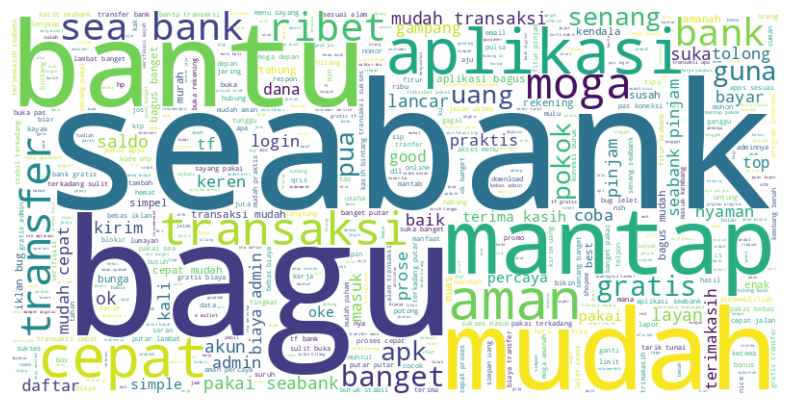

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Menggabungkan teks dari kolom 'steming_data'
text = ' '.join(df['steming_data'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp','lu','deh','fyp', 'ya', 'gue', 'sih'])

wc = WordCloud(stopwords=stopwords, background_color="white", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

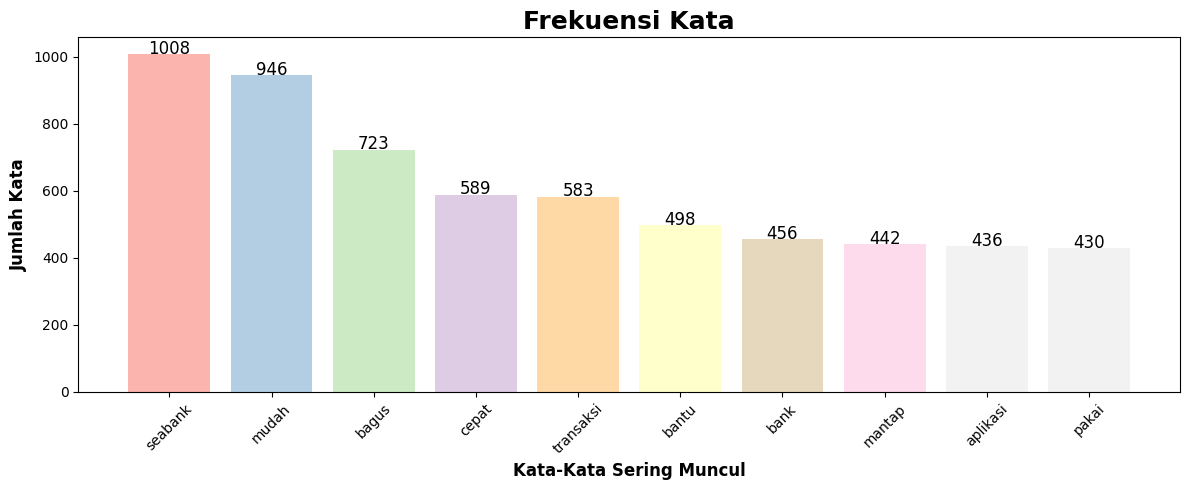

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

all_text = ' '.join(df["steming_data"].astype(str))
all_words = all_text.split()


stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'fyp', 'ya', 'gue', 'sih', 'yg', 'nya', 'aja', 'sdh', 'gak', 'ga'])

filtered_words = [word for word in all_words if word.lower() not in stopwords]
word_counts = Counter(filtered_words)
top_words = word_counts.most_common(10)
word, count = zip(*top_words)

colors = plt.cm.Pastel1(range(len(word)))

# Plot
plt.figure(figsize=(12, 5))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Tampilkan jumlah di atas bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2, num + 1, str(num), fontsize=12, color='black', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
df.to_csv('Hasil_Preprocessing_Data.csv',encoding='utf8', index=False);

# ***PELEBALAN DATA METODE LAXICON BASED***

In [ ]:
import pandas as pd

data = pd.read_csv("Hasil_Preprocessing_Data.csv")
data.info()
pd.set_option('display.max_colwidth', None)
data.head(50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5623 entries, 0 to 5622
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              5623 non-null   object
 1   Username          5623 non-null   object
 2   Rating            5623 non-null   int64 
 3   Review Text       5623 non-null   object
 4   cleaning          5574 non-null   object
 5   case_folding      5574 non-null   object
 6   normalisasi       5572 non-null   object
 7   tokenize          5623 non-null   object
 8   stopword removal  5623 non-null   object
 9   steming_data      5523 non-null   object
dtypes: int64(1), object(9)
memory usage: 439.4+ KB


,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize,stopword removal,steming_data
0,2026-04-25 11:58:49,Pengguna Google,5,sangat puas,sangat puas,sangat puas,sangat puas,"['sangat', 'puas']",['puas'],puas
1,2026-04-25 11:57:16,Pengguna Google,4,Semoga untuk penyimpanan tetap aman.Sekedar saran nama pengirim/penerima ditampilkan penuh supaya lebih jelas.,Semoga untuk penyimpanan tetap aman Sekedar saran nama pengirim penerima ditampilkan penuh supaya lebih jelas,semoga untuk penyimpanan tetap aman sekedar saran nama pengirim penerima ditampilkan penuh supaya lebih jelas,semoga untuk penyimpanan tetap aman sekedar saran nama pengirim penerima ditampilkan penuh supaya lebih jelas,"['semoga', 'untuk', 'penyimpanan', 'tetap', 'aman', 'sekedar', 'saran', 'nama', 'pengirim', 'penerima', 'ditampilkan', 'penuh', 'supaya', 'lebih', 'jelas']","['semoga', 'penyimpanan', 'aman', 'sekedar', 'saran', 'nama', 'pengirim', 'penerima', 'ditampilkan', 'penuh']",moga simpan aman dar saran nama kirim terima tampil penuh
2,2026-04-25 11:52:01,Pengguna Google,5,mantap bosku 🙏,mantap bosku,mantap bosku,mantap bosku,"['mantap', 'bosku']","['mantap', 'bosku']",mantap bos
3,2026-04-25 11:24:37,Pengguna Google,5,Àplikasi bank digital yang bagus cepat dan lancar,plikasi bank digital yang bagus cepat dan lancar,plikasi bank digital yang bagus cepat dan lancar,plikasi bank digital yang bagus cepat dan lancar,"['plikasi', 'bank', 'digital', 'yang', 'bagus', 'cepat', 'dan', 'lancar']","['plikasi', 'bank', 'digital', 'bagus', 'cepat', 'lancar']",plikasi bank digital bagus cepat lancar
4,2026-04-25 10:59:01,Pengguna Google,1,saya tidak bisa membuka seabank,saya tidak bisa membuka seabank,saya tidak bisa membuka seabank,saya tidak bisa membuka seabank,"['saya', 'tidak', 'bisa', 'membuka', 'seabank']","['membuka', 'seabank']",buka seabank
5,2026-04-25 10:36:54,Pengguna Google,4,gratis lagi dong buat tf ke dana dan ewallet lainnya,gratis lagi dong buat tf ke dana dan ewallet lainnya,gratis lagi dong buat tf ke dana dan ewallet lainnya,gratis lagi dong buat tf ke dana dan ewallet lainnya,"['gratis', 'lagi', 'dong', 'buat', 'tf', 'ke', 'dana', 'dan', 'ewallet', 'lainnya']","['gratis', 'tf', 'dana', 'ewallet']",gratis tf dana ewallet
6,2026-04-25 09:58:35,Pengguna Google,5,"Transaksi cepat , murah dana aman",Transaksi cepat murah dana aman,transaksi cepat murah dana aman,transaksi cepat murah dana aman,"['transaksi', 'cepat', 'murah', 'dana', 'aman']","['transaksi', 'cepat', 'murah', 'dana', 'aman']",transaksi cepat murah dana aman
7,2026-04-25 09:33:28,Pengguna Google,4,mantap...beda sama yang lain,mantap beda sama yang lain,mantap beda sama yang lain,mantap beda sama yang lain,"['mantap', 'beda', 'sama', 'yang', 'lain']","['mantap', 'beda']",mantap beda
8,2026-04-25 09:24:12,Pengguna Google,5,Sangat sangat membantu.,Sangat sangat membantu,sangat sangat membantu,sangat sangat membantu,"['sangat', 'sangat', 'membantu']",['membantu'],bantu
9,2026-04-25 08:58:26,Pengguna Google,5,sangat membantu!!!,sangat membantu,sangat membantu,sangat membantu,"['sangat', 'membantu']",['membantu'],bantu


In [ ]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5523 entries, 0 to 5622
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              5523 non-null   object
 1   Username          5523 non-null   object
 2   Rating            5523 non-null   int64 
 3   Review Text       5523 non-null   object
 4   cleaning          5523 non-null   object
 5   case_folding      5523 non-null   object
 6   normalisasi       5523 non-null   object
 7   tokenize          5523 non-null   object
 8   stopword removal  5523 non-null   object
 9   steming_data      5523 non-null   object
dtypes: int64(1), object(9)
memory usage: 474.6+ KB


In [ ]:
data = pd.DataFrame(data[['steming_data']])
pd.set_option('display.max_colwidth', None)
data.head(50)

,steming_data
0,puas
1,moga simpan aman dar saran nama kirim terima tampil penuh
2,mantap bos
3,plikasi bank digital bagus cepat lancar
4,buka seabank
5,gratis tf dana ewallet
6,transaksi cepat murah dana aman
7,mantap beda
8,bantu
9,bantu


In [ ]:
import pandas as pd
import requests

# Unduh kamus leksikon positif dan negatif dari GitHub
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0])

# Fungsi untuk menentukan sentimen dan menghitung skornya
def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count
        if sentiment_score > 0:
            sentiment = "Positif"
        elif sentiment_score < 0:
            sentiment = "Negatif"
        else:
            sentiment = "Netral"
        return sentiment_score, sentiment
    return 0, "Netral"


# Tentukan sentimen dan skor untuk setiap ulasan
data[['Score', 'Sentiment']] = data['steming_data'].apply(lambda x: pd.Series(determine_sentiment(x)))

pd.set_option('display.max_colwidth', None)
# Tampilkan hasilnya
data.head(60)


,steming_data,Score,Sentiment
0,puas,1,Positif
1,moga simpan aman dar saran nama kirim terima tampil penuh,2,Positif
2,mantap bos,2,Positif
3,plikasi bank digital bagus cepat lancar,0,Netral
4,buka seabank,0,Netral
5,gratis tf dana ewallet,2,Positif
6,transaksi cepat murah dana aman,2,Positif
7,mantap beda,0,Netral
8,bantu,0,Netral
9,bantu,0,Netral


/tmp/ipykernel_547/2927411638.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')


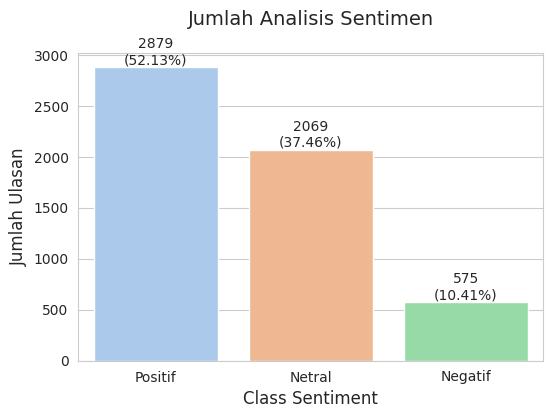

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = data['Sentiment'].value_counts()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)

total = len(data['Sentiment'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

In [ ]:
data.to_csv('Hasil_Labelling_Data.csv',encoding='utf8', index=False)

**WORDCLOUD**

---



In [ ]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_Data.csv")
pd.set_option('display.max_colwidth', None)
data.head(50)

,steming_data,Score,Sentiment
0,puas,1,Positif
1,moga simpan aman dar saran nama kirim terima tampil penuh,2,Positif
2,mantap bos,2,Positif
3,plikasi bank digital bagus cepat lancar,0,Netral
4,buka seabank,0,Netral
5,gratis tf dana ewallet,2,Positif
6,transaksi cepat murah dana aman,2,Positif
7,mantap beda,0,Netral
8,bantu,0,Netral
9,bantu,0,Netral


In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Pisahkan dataset berdasarkan sentimen
sentimen_Neutral = data[data['Sentiment'] == 'Netral']['steming_data'].str.cat(sep=' ')
sentimen_Negative = data[data['Sentiment'] == 'Negatif']['steming_data'].str.cat(sep=' ')
sentimen_Positive = data[data['Sentiment'] == 'Positif']['steming_data'].str.cat(sep=' ')

In [ ]:
# Fungsi untuk membuat dan menampilkan WordCloud
def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, random_state=42, max_font_size=100, background_color='white').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

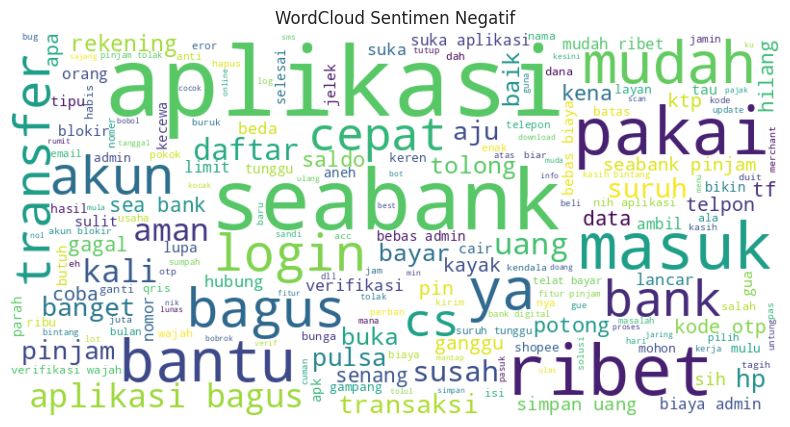

In [ ]:
# Membuat WordCloud untuk sentimen Negatif
create_wordcloud(sentimen_Negative, 'WordCloud Sentimen Negatif')

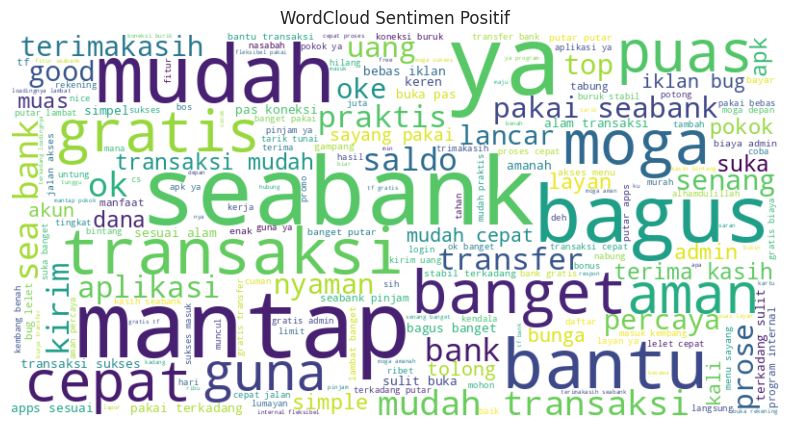

In [ ]:
# Membuat WordCloud untuk sentimen Positif
create_wordcloud(sentimen_Positive, 'WordCloud Sentimen Positif')

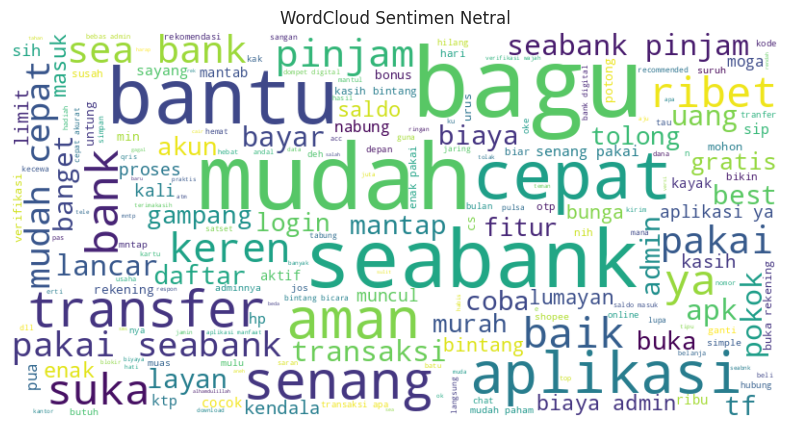

In [ ]:
# Membuat WordCloud untuk sentimen Netral
create_wordcloud(sentimen_Neutral, 'WordCloud Sentimen Netral')

# ***SPLITTING DATASET***

In [ ]:
import pandas as pd

file_path = 'Hasil_Labelling_Data.csv'
data = pd.read_csv(file_path)

data.info()
pd.set_option('display.max_colwidth', None)
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5523 entries, 0 to 5522
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   steming_data  5523 non-null   object
 1   Score         5523 non-null   int64 
 2   Sentiment     5523 non-null   object
dtypes: int64(1), object(2)
memory usage: 129.6+ KB


,steming_data,Score,Sentiment
0,puas,1,Positif
1,moga simpan aman dar saran nama kirim terima tampil penuh,2,Positif
2,mantap bos,2,Positif
3,plikasi bank digital bagus cepat lancar,0,Netral
4,buka seabank,0,Netral


In [ ]:
from sklearn.model_selection import train_test_split
# 1. Ubah import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Memastikan tidak ada data kosong pada kolom 'steming_data'
cleaned_data = data.dropna(subset=['steming_data'])

X = cleaned_data['steming_data']
y = cleaned_data['Sentiment']

# Pembagian data latih dan data uji (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Jumlah data latih:", len(X_train))
print("Jumlah data uji:", len(X_test))
print('===========================')


Jumlah data latih: 4418
Jumlah data uji: 1105


In [ ]:
vectorizer = TfidfVectorizer(max_df=0.9, min_df=3, max_features=3000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

X_train_vec.shape, X_test_vec.shape

((4418, 2478), (1105, 2478))

In [ ]:
# Mencetak bentuk matriks
print("Shape of X_train_vec:", X_train_vec.shape)
print("Shape of X_test_vec:", X_test_vec.shape)

# Mencetak isi vektor (sekarang berupa nilai desimal bobot TF-IDF, bukan lagi angka bulat/integer)
print("\nX_train_vec (as array):")
print(X_train_vec.toarray())

print("\nX_test_vec (as array):")
print(X_test_vec.toarray())

Shape of X_train_vec: (4418, 2478)
Shape of X_test_vec: (1105, 2478)

X_train_vec (as array):
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

X_test_vec (as array):
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
import pandas as pd

# Assuming X_train_vec is your csr_matrix
df_X_train_vec = pd.DataFrame(X_train_vec.toarray()) # Convert to DataFrame first

# Now you can save it to a CSV
df_X_train_vec.to_csv('vector.csv', encoding='utf8', index=False)

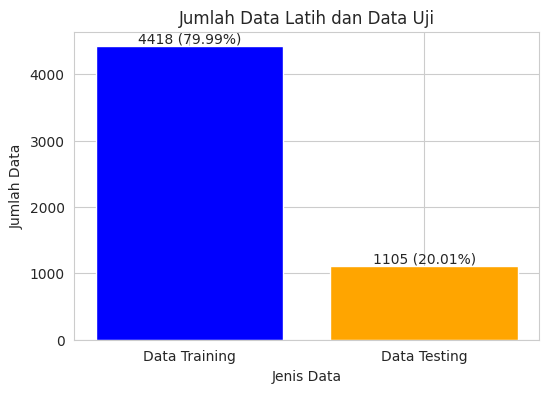

In [ ]:
import matplotlib.pyplot as plt


train_size = len(X_train)
test_size = len(X_test)

plt.figure(figsize=(6, 4))
bars = plt.bar(['Data Training', 'Data Testing'], [train_size, test_size], color=['blue', 'orange'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height} ({height / (train_size + test_size) * 100:.2f}%)',
             ha='center', va='bottom')

plt.title('Jumlah Data Latih dan Data Uji')
plt.xlabel('Jenis Data')
plt.ylabel('Jumlah Data')
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC

# 1. Ekstraksi fitur teks ke numerik
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 2. Terapkan SMOTE pada data latih numerik
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_vec, y_train)

# 3. Latih model SVM menggunakan data hasil SMOTE dengan Regularisasi lebih baik untuk menghindari Overfitting
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_smote, y_train_smote)


SVC(C=0.5, kernel='linear', random_state=42)

# ***PENERAPAN ALGORITMA SVM***

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Use the svm_model already trained with SMOTE from the previous cell (XMKY0ag53iFc)

results = {}

# Predict using the svm_model trained with SMOTE
y_pred = svm_model.predict(X_test_vec)

# Store results for the SVM model
results["SVM"] = {
    "accuracy": accuracy_score(y_test, y_pred),
    "classification_report": classification_report(y_test, y_pred, output_dict=True),
    "confusion_matrix": confusion_matrix(y_test, y_pred)
}


Confusion Matrix for SVM:


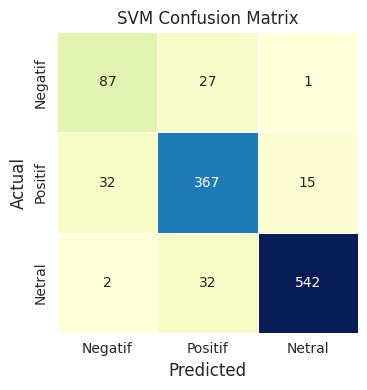

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for model_name, result in results.items():
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt='d',
        cmap="YlGnBu",
        cbar=False,
        xticklabels=['Negatif','Positif','Netral'],
        yticklabels=['Negatif','Positif','Netral'],
        ax=ax,
        square=True,
        linewidths=0.5
    )
    print(f"\nConfusion Matrix for {model_name}:")
    ax.set_title(f"{model_name} Confusion Matrix", fontsize=12)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)


    plt.tight_layout()
    plt.show()


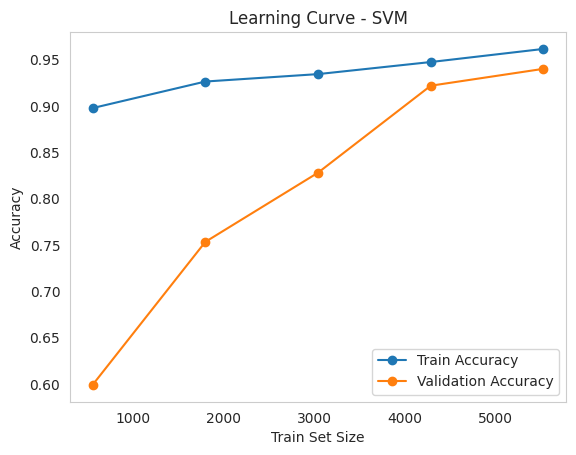

In [ ]:
# learning curve
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
	svm_model, X_train_smote, y_train_smote, cv=5, scoring='accuracy'
)

# Rata-rata accuracy
train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_scores_mean, 'o-', label="Train Accuracy")
plt.plot(train_sizes, val_scores_mean, 'o-', label="Validation Accuracy")
plt.legend()
plt.xlabel("Train Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - SVM")
plt.grid()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

accuracies = {model: result['accuracy'] for model, result in results.items()}
print("Accuracy Model SVM : ", accuracies)

Accuracy Model SVM :  {'SVM': 0.9013574660633484}


In [ ]:
from IPython.display import display

for model_name, result in results.items():
    print(f"\nClassification Report for {model_name}:")

    report_df = pd.DataFrame(result['classification_report']).transpose()

    styled_df = report_df.style.background_gradient(cmap="coolwarm")
    styled_df = styled_df.format(precision=3)
    display(styled_df)


Classification Report for SVM:


,precision,recall,f1-score,support
Negatif,0.574,0.739,0.646,115.000
Netral,0.764,0.843,0.801,414.000
Positif,0.972,0.844,0.903,576.000
accuracy,0.833,0.833,0.833,0.833
macro avg,0.770,0.809,0.784,1105.000
weighted avg,0.853,0.833,0.838,1105.000


In [ ]:
import pickle

# 1. Menyimpan Petugas Penerjemah (TF-IDF Vectorizer)
with open('tfidf_vectorizer_smote.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)

# 2. Menyimpan Petugas Pengambil Keputusan (Model SVM)
with open('svm_model_smote.pkl', 'wb') as file:
    pickle.dump(svm_model, file)

print("TF-IDF Vectorizer dan Model SVM berhasil disimpan!")

TF-IDF Vectorizer dan Model SVM berhasil disimpan!


In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


# ***RATING***

In [ ]:
import pandas as pd

data = pd.read_csv("Hasil_Preprocessing_Data.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5623 entries, 0 to 5622
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              5623 non-null   object
 1   Username          5623 non-null   object
 2   Rating            5623 non-null   int64 
 3   Review Text       5623 non-null   object
 4   cleaning          5574 non-null   object
 5   case_folding      5574 non-null   object
 6   normalisasi       5572 non-null   object
 7   tokenize          5623 non-null   object
 8   stopword removal  5623 non-null   object
 9   steming_data      5523 non-null   object
dtypes: int64(1), object(9)
memory usage: 439.4+ KB


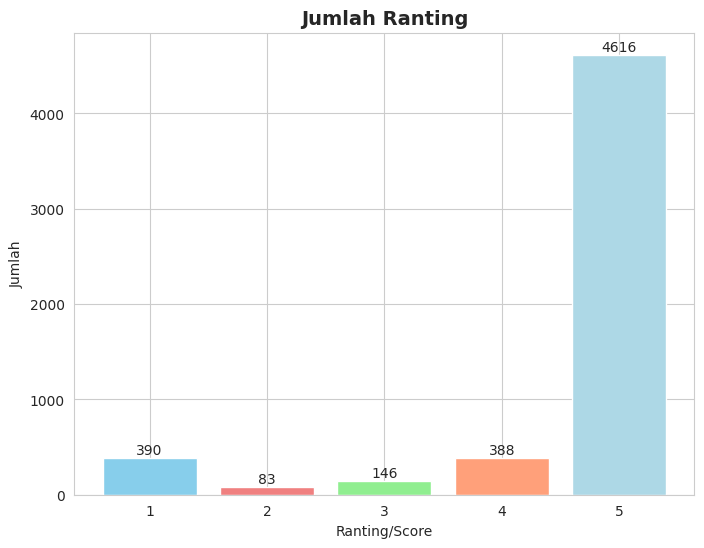

In [ ]:
import matplotlib.pyplot as plt

rating_counts = data['Rating'].value_counts()
rating_counts = rating_counts.sort_index()

colors = ['skyblue', 'lightcoral', 'lightgreen', 'lightsalmon', 'lightblue']

plt.figure(figsize=(8, 6))
bars = plt.bar(rating_counts.index, rating_counts.values, color=colors)
plt.title('Jumlah Ranting', fontsize=14, fontweight='bold')
plt.xlabel('Ranting/Score')
plt.ylabel('Jumlah')
plt.xticks(rating_counts.index)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, str(int(height)), ha='center', va='bottom')

plt.show()